In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data/raw/UTKFace") 

In [ ]:
def parse_utkface_filenames(directory):
    data = []
    for file in directory.glob("*.jpg"):
        parts = file.name.split('_')
        if len(parts) >= 3:
            try:
                age = int(parts[0])
                gender = int(parts[1])
                ethnicity = int(parts[2])
                data.append({
                    "path": f"data/raw/UTKFace/{file.name}",
                    "age": age,
                    "gender": "male" if gender == 0 else "female",
                    "ethnicity": ethnicity
                })
            except ValueError:
                continue 
    return pd.DataFrame(data)

df = parse_utkface_filenames(DATA_DIR)
print(f"Nombre d'images trouvées : {len(df)}")
df.head()


Nombre d'images trouvées : 23705


,path,age,gender,ethnicity
0,..\data\raw\UTKFace\100_0_0_20170112213500903....,100,male,0
1,..\data\raw\UTKFace\100_0_0_20170112215240346....,100,male,0
2,..\data\raw\UTKFace\100_1_0_20170110183726390....,100,female,0
3,..\data\raw\UTKFace\100_1_0_20170112213001988....,100,female,0
4,..\data\raw\UTKFace\100_1_0_20170112213303693....,100,female,0


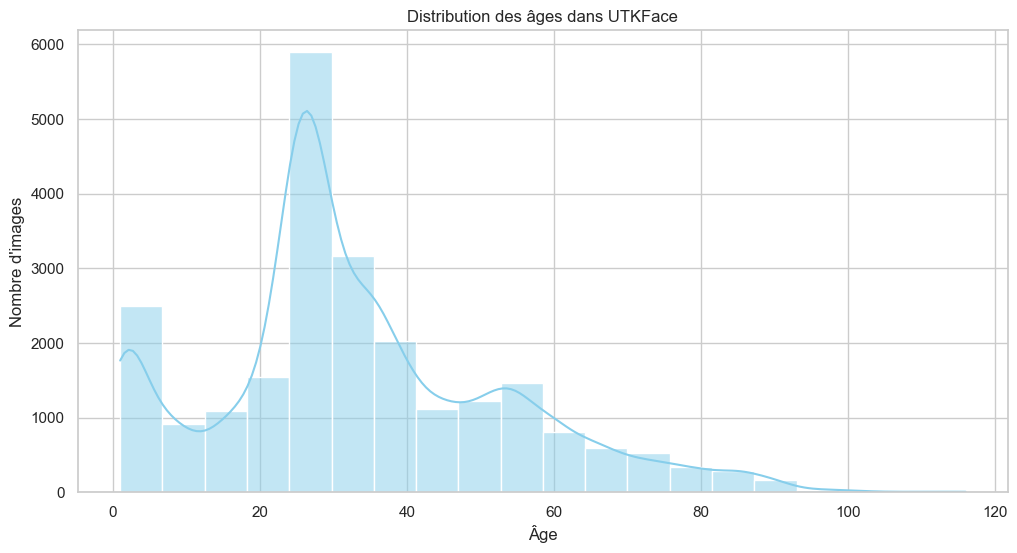

Âge minimum : 1
Âge maximum : 116
Âge moyen : 33.30


In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Distribution des âges dans UTKFace")
plt.xlabel("Âge")
plt.ylabel("Nombre d'images")
plt.show()

print(f"Âge minimum : {df['age'].min()}")
print(f"Âge maximum : {df['age'].max()}")
print(f"Âge moyen : {df['age'].mean():.2f}")

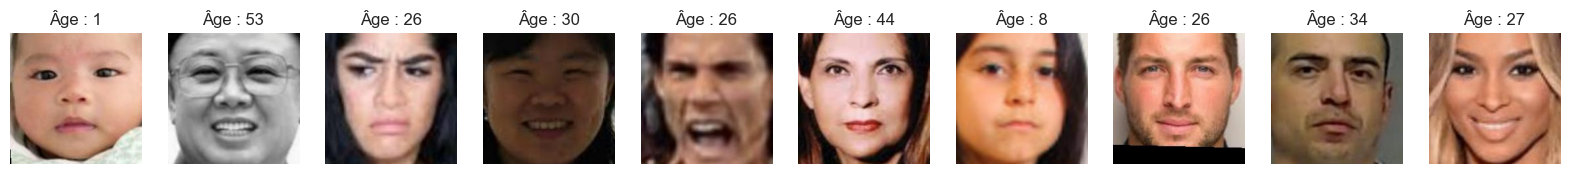

In [ ]:
def show_samples(dataframe, num_samples=10):
    samples = dataframe.sample(num_samples)
    plt.figure(figsize=(20, 4))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Âge : {row['age']}")
        plt.axis('off')
    plt.show()

show_samples(df)

In [ ]:
# On crée 10 tranches d'âge
df['age_bin'] = pd.cut(df['age'], bins=10, labels=False)

# On vérifie si une tranche est trop pauvre en données
print(df['age_bin'].value_counts().sort_index())

# Sauvegarde pour la phase de training
df.to_csv("../data/processed/utkface_metadata.csv", index=False)
print("Métadonnées sauvegardées dans data/processed/")

age_bin
0    3413
1    3490
2    8204
3    3310
4    2518
5    1545
6     707
7     451
8      49
9      18
Name: count, dtype: int64
Métadonnées sauvegardées dans data/processed/


: 